In [2]:
# Imports, setup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# 3 method families
info_methods = [
    'MSP', 'PPL', 'MTE', 'TokenSAR'
]

consistency_methods = [
    'NumSemSets', 'DegMat_NLI_score_entail', 'DegMat_NLI_score_contra', 
    'DegMat_Jaccard_score', 'EigValLaplacian_NLI_score_entail', 
    'EigValLaplacian_NLI_score_contra', 'EigValLaplacian_Jaccard_score', 
    'Eccentricity_NLI_score_entail', 'Eccentricity_NLI_score_contra',
    'Eccentricity_Jaccard_score', 'LexicalSimilarity_rouge1', 
    'LexicalSimilarity_rouge2', 'LS_rL', 'LexicalSimilarity_BLEU'
]

# LS_rL is LexicalSimilarity_rougeL

hybrid_methods = [
    'SentenceSAR', 'SAR', 'SE'
]
# SE is Semantic Entropy

# Create a dictionary to map each method to its color
color_map = {}
for method in info_methods:
    color_map[method] = 'cornflowerblue' # Blue for Information-Theoretic
for method in consistency_methods:
    color_map[method] = 'mediumseagreen'   # Green for Consistency-Based
for method in hybrid_methods:
    color_map[method] = 'salmon'         # Red/Orange for Hybrid

## TESTING: gemma_medmcqa_direct.csv

In [4]:
# Load CSVs with PRR Scores
df_gemma_medmcqa_direct = pd.read_csv('gemma_medmcqa_direct.csv', index_col=0)
df_gemma_medmcqa_reasoning = pd.read_csv('gemma_medmcqa_reasoning.csv', index_col=0)

df_gemma_medmcqa_direct.head()

,r1,r2,rL,BLEU,Bert,Sbert,Accuracy,AlignScore
MSP,0.364411,NaN,0.364411,0.364411,0.310839,0.312934,0.367045,0.357672
PPL,0.364411,NaN,0.364411,0.364411,0.310839,0.312934,0.367045,0.357672
MTE,0.366909,NaN,0.366909,0.366909,0.313280,0.315377,0.369486,0.360206
TokenSAR,0.363410,NaN,0.363410,0.363410,0.309605,0.311820,0.366044,0.356770
NumSemSets,0.163987,NaN,0.163987,0.163987,0.153713,0.147812,0.163175,0.161755


In [5]:
quality_metric = 'Accuracy'

gemma_medmcqa_direct_data = df_gemma_medmcqa_direct[quality_metric]
gemma_medmcqa_reasoning_data = df_gemma_medmcqa_reasoning[quality_metric]
diff_data = gemma_medmcqa_reasoning_data - gemma_medmcqa_direct_data

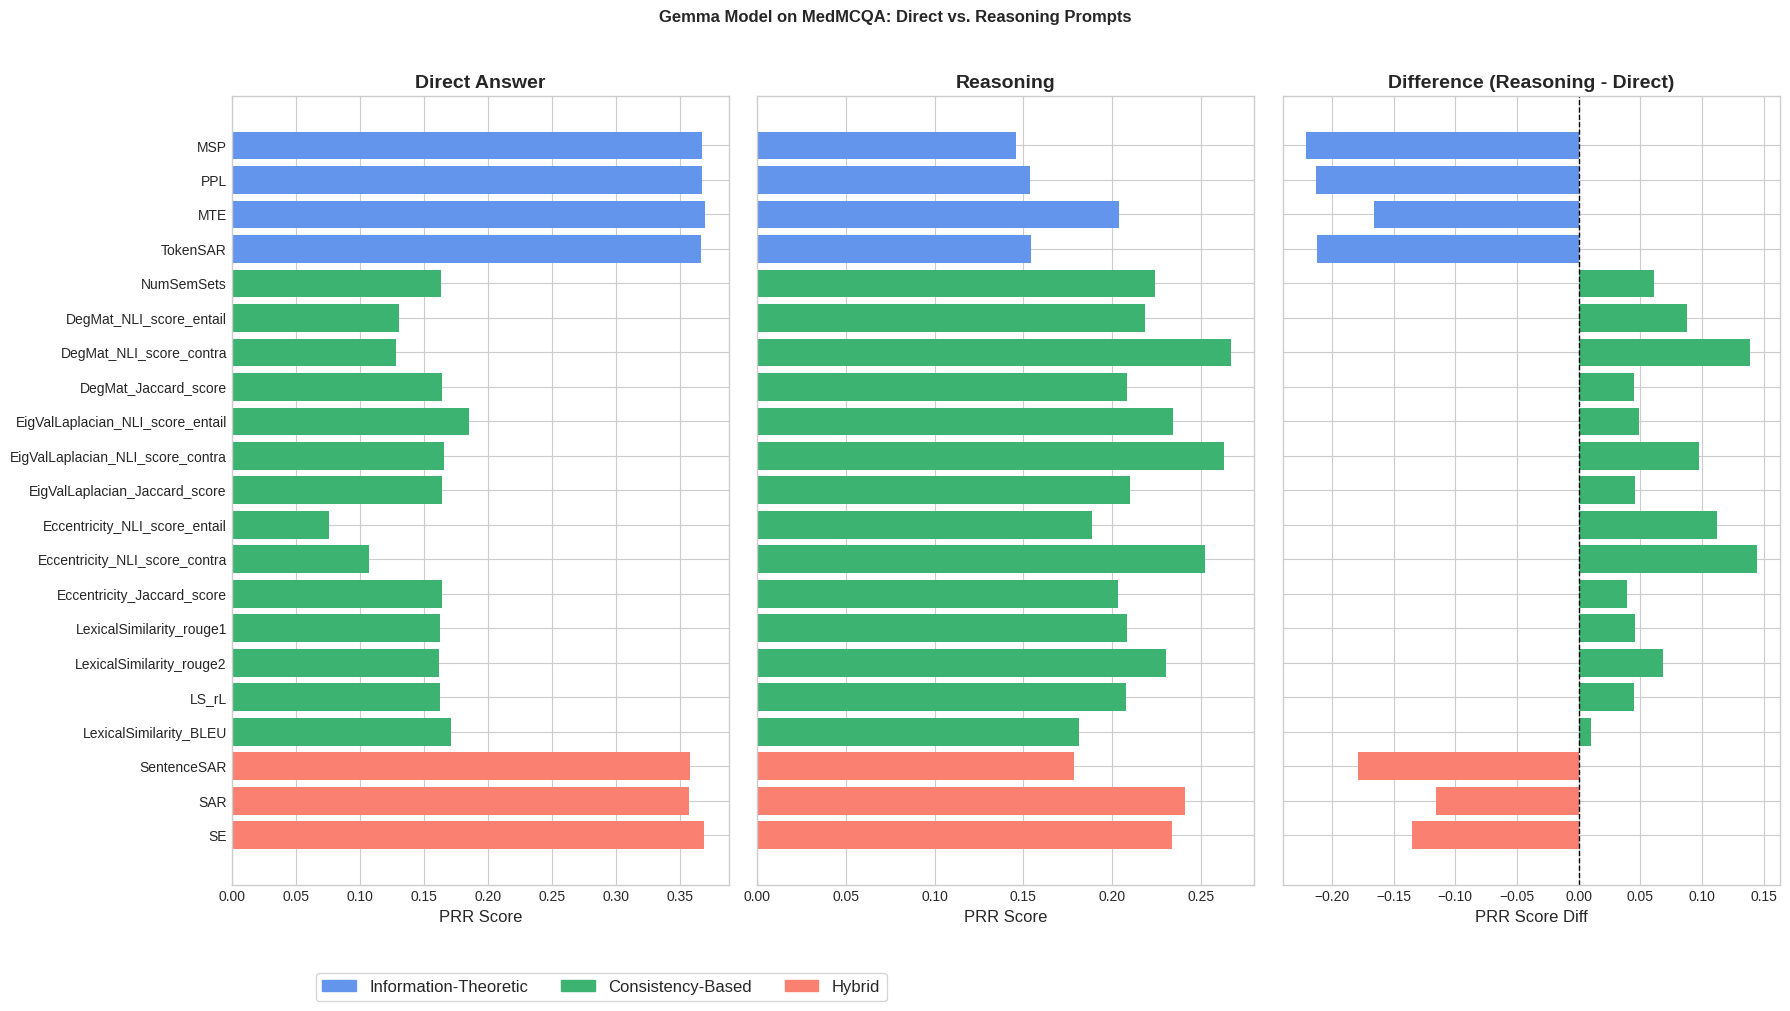

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], gemma_medmcqa_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], gemma_medmcqa_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Gemma Model on MedMCQA: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()

# bars = ax.barh(gemma_medmcqa_direct_data.index, gemma_medmcqa_direct_data.values)

# ax.set_xlabel('PRR Score', fontsize=12)
# ax.set_ylabel('')
# ax.set_title('gemma medmcqa-direct', fontsize=14, fontweight='bold')

# # This is stupid but I don't care
# bar_colors = [color_map[method] for method, _ in gemma_medmcqa_direct_data.items()]

# for idx, bar in enumerate(bars):
#     bar.set_color(bar_colors[idx])


# ax.legend(handles=legend_patches, loc='lower right', fontsize=11)

# plt.tight_layout()
# plt.show()

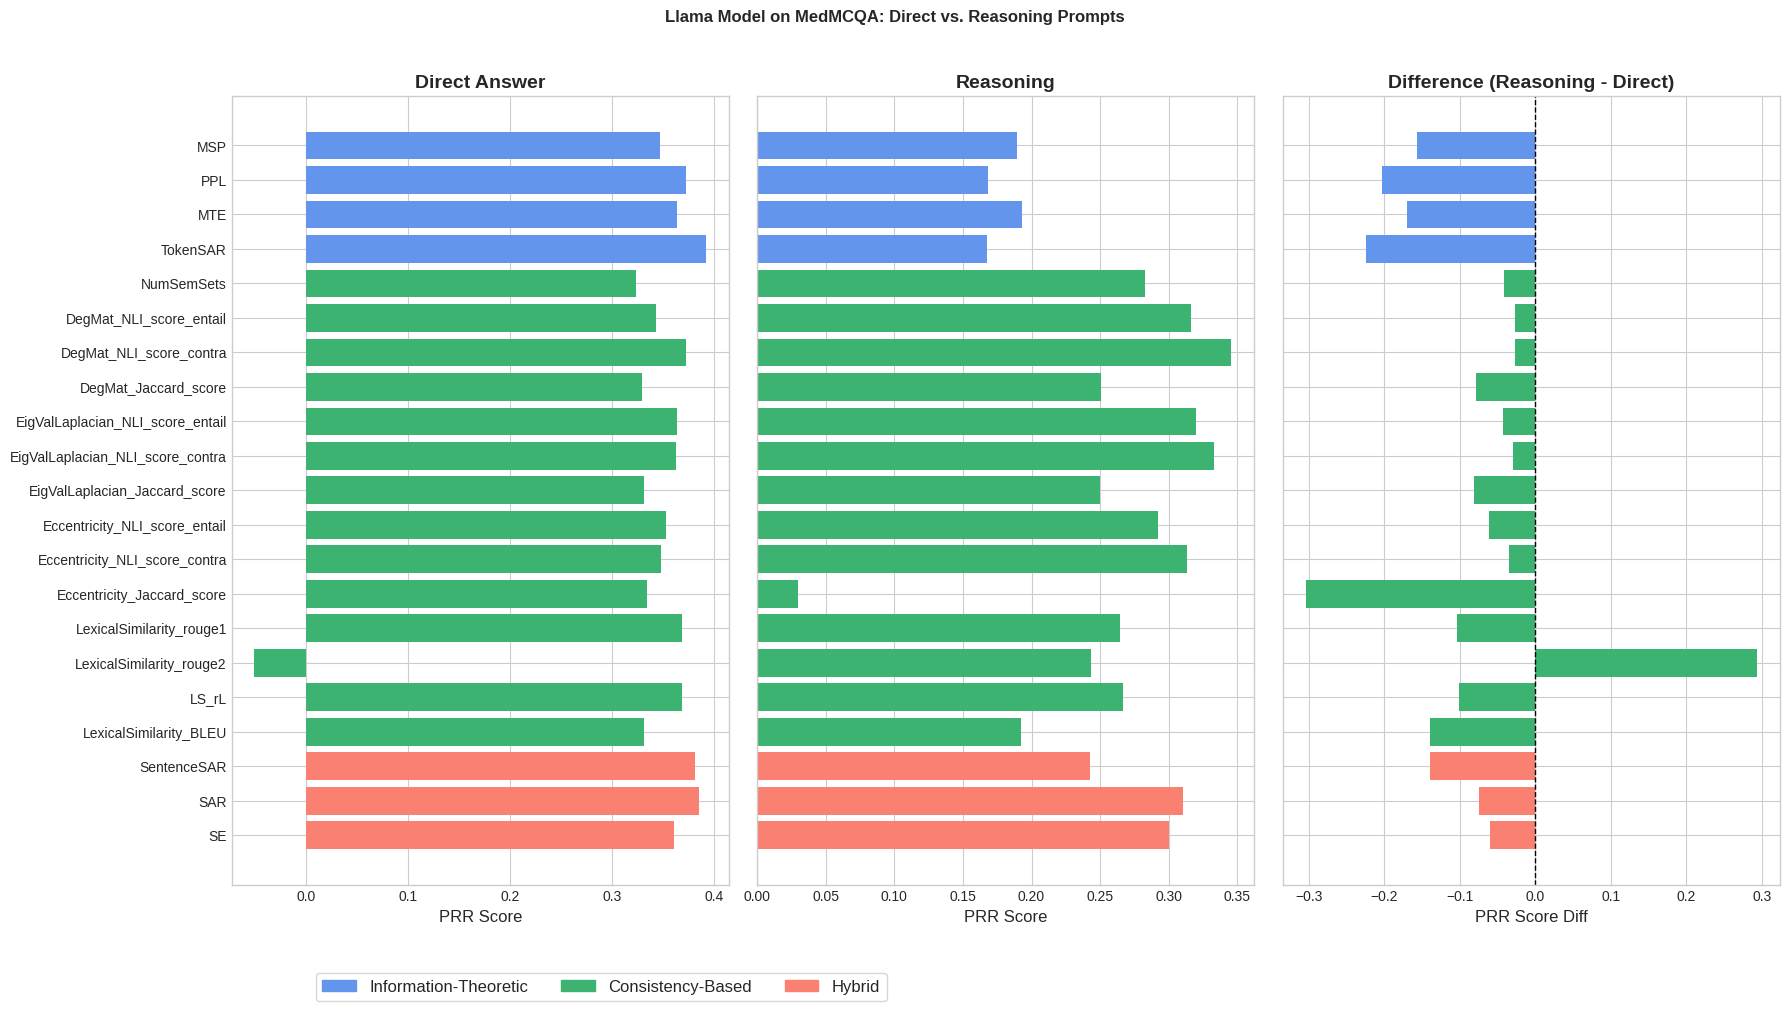

In [7]:
# Load CSVs with PRR Scores
df_llama_medmcqa_direct = pd.read_csv('llama_medmcqa_direct.csv', index_col=0)
df_llama_medmcqa_reasoning = pd.read_csv('llama_medmcqa_reasoning.csv', index_col=0)

df_llama_medmcqa_direct.head()
llama_medmcqa_direct_data = df_llama_medmcqa_direct[quality_metric]
llama_medmcqa_reasoning_data = df_llama_medmcqa_reasoning[quality_metric]
diff_data = llama_medmcqa_reasoning_data - llama_medmcqa_direct_data

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], llama_medmcqa_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], llama_medmcqa_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Llama Model on MedMCQA: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()


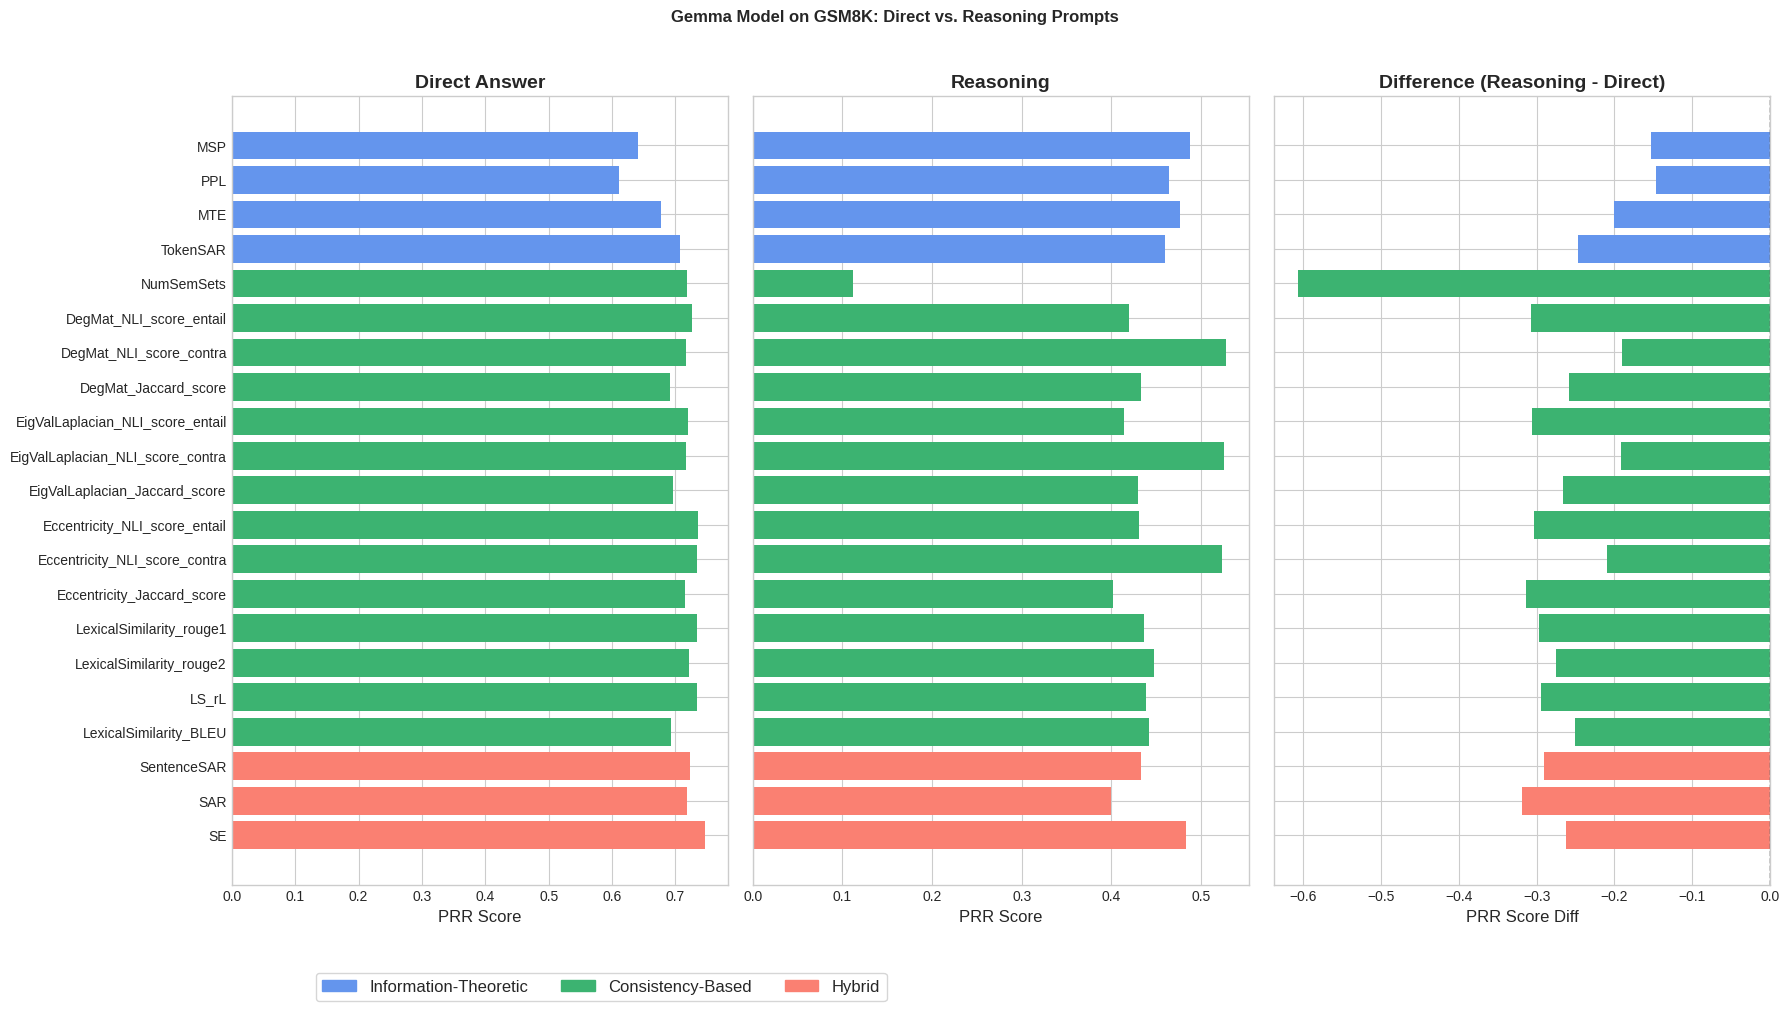

In [8]:
# Load CSVs with PRR Scores
df_gemma_gsm8k_direct = pd.read_csv('gemma_gsm8k_direct.csv', index_col=0)
df_gemma_gsm8k_reasoning = pd.read_csv('gemma_gsm8k_reasoning.csv', index_col=0)

df_gemma_gsm8k_direct.head()
gemma_gsm8k_direct_data = df_gemma_gsm8k_direct[quality_metric]
gemma_gsm8k_reasoning_data = df_gemma_gsm8k_reasoning[quality_metric]
diff_data = gemma_gsm8k_reasoning_data - gemma_gsm8k_direct_data

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], gemma_gsm8k_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], gemma_gsm8k_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Gemma Model on GSM8K: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()


## All-Inclusive plot

In [9]:
df_gemma_gsm8k_direct

,r1,r2,rL,BLEU,Bert,Sbert,Accuracy,AlignScore
MSP,0.643671,0.5,0.643671,0.641208,0.336305,0.285705,0.641208,0.568247
PPL,0.613950,0.5,0.613950,0.611282,0.288900,0.253461,0.611282,0.553944
MTE,0.679681,0.5,0.679681,0.677468,0.310301,0.297951,0.677468,0.629519
TokenSAR,0.709133,0.5,0.709133,0.707123,0.312441,0.279946,0.707123,0.650034
NumSemSets,0.720156,0.5,0.720156,0.718222,0.392773,0.331550,0.718222,0.627595
DegMat_NLI_score_entail,0.728516,0.5,0.728516,0.726640,0.377699,0.331868,0.726640,0.642509
DegMat_NLI_score_contra,0.719356,0.5,0.719356,0.717416,0.378425,0.332386,0.717416,0.634227
DegMat_Jaccard_score,0.693584,0.5,0.693584,0.691467,0.361400,0.310946,0.691467,0.611130
EigValLaplacian_NLI_score_entail,0.721754,0.5,0.721754,0.719831,0.375421,0.330878,0.719831,0.640720
EigValLaplacian_NLI_score_contra,0.718620,0.5,0.718620,0.716676,0.390511,0.344099,0.716676,0.636239


In [10]:
prr_metric_to_plot = 'Accuracy' 
# --------------------

datasets = ['medmcqa', 'gsm8k']
models = ['gemma', 'llama']
dataframes = {}



# def create_bar_chart(ax, data, title, lim=False):
#     bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
#     ax.set_title(title, fontsize=14, fontweight='bold')
#     # ax.set_xlabel(xlabel, fontsize=12)
#     ax.tick_params(axis='x', labelsize=10)
#     ax.set_ylabel('')
#     ax.invert_yaxis()
#     if lim:
#         ax.set_xlim(0, 1)

# Load info for all 4 models
for model in models:
    for ds in datasets:
        # Assuming the file names follow a consistent pattern
        direct_df = pd.read_csv(f'{model}_{ds}_direct.csv', index_col=0)
        reasoning_df = pd.read_csv(f'{model}_{ds}_reasoning.csv', index_col=0)

        # A little too strange to include (e.g. NaN for some direct datasets due to
        # lack of 2-grams)
        direct_df.drop(['LexicalSimilarity_rouge2'], inplace=True)
        reasoning_df.drop(['LexicalSimilarity_rouge2'], inplace=True)

        dataframes[f'{model}_{ds}_direct'] = direct_df
        dataframes[f'{model}_{ds}_reasoning'] = reasoning_df

def gen_model_plot(model_name, datasets, dataframes, prr_metric, color_map):
    fig, axes = plt.subplots(2, 3, figsize=(22, 14), sharey=True)

    # Loop thru each dataset. each loop creates a row of plots.
    for i, ds_name in enumerate(datasets):
        df_direct = dataframes.get(f'{model_name}_{ds_name}_direct')
        df_reasoning = dataframes.get(f'{model_name}_{ds_name}_reasoning')

        direct_data = df_direct[prr_metric]
        reasoning_data = df_reasoning[prr_metric]
        diff_data = reasoning_data - direct_data

        def create_bar_chart(ax, data, lim=False):
            bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
            # ax.set_title(title, fontsize=16, fontweight='bold')
            # ax.set_xlabel(xlabel, fontsize=12)
            ax.tick_params(axis='x', labelsize=10)
            ax.set_ylabel('')
            ax.invert_yaxis()
            if lim:
                ax.set_xlim(0, 1)
            
        create_bar_chart(axes[i, 0], direct_data)
        create_bar_chart(axes[i, 1], reasoning_data)
        create_bar_chart(axes[i, 2], diff_data)

        axes[i, 2].axvline(0, color='black', linestyle='--', linewidth=1)
        axes[i, 0].set_ylabel(ds_name.upper(), fontsize=16, fontweight='bold', labelpad=15)
    # Final formatting
    # for i in range(2):
    #     # PRR Score: Based on Accuracy
    #     axes[i, 0].set_xlabel(f'PRR Score', fontsize=14)
    #     axes[i, 1].set_xlabel(f'PRR Score', fontsize=14)
    #     axes[i, 2].set_xlabel('PRR Score Diff', fontsize=14)

    axes[0, 0].set_title("Direct Answer", fontsize=18, fontweight='bold', pad=20)
    axes[0, 1].set_title("Reasoning", fontsize=18, fontweight='bold', pad=20)
    axes[0, 2].set_title("Diff (Reasoning - Direct)", fontsize=18, fontweight='bold', pad=20)

    # Set shared x-axis labels for the bottom row
    axes[1, 0].set_xlabel(f'PRR Score', fontsize=16) 
    axes[1, 1].set_xlabel(f'PRR Score', fontsize=16) 
    axes[1, 2].set_xlabel('PRR Score Diff', fontsize=16) 
    
    legend_patches = [
        mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
        mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
        mpatches.Patch(color='salmon', label='Hybrid')
    ]

    fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, 0), 
               ncol=3, fontsize=16, frameon=True, title_fontsize=14)
    
    # Main title
    fig.suptitle(f'{model_name.capitalize()} Model: Direct vs. Reasoning UQ Analysis',
                fontsize=24, fontweight='bold')
    fig.tight_layout(rect=[0, 0.06, 1, 0.94])

    plt.show()


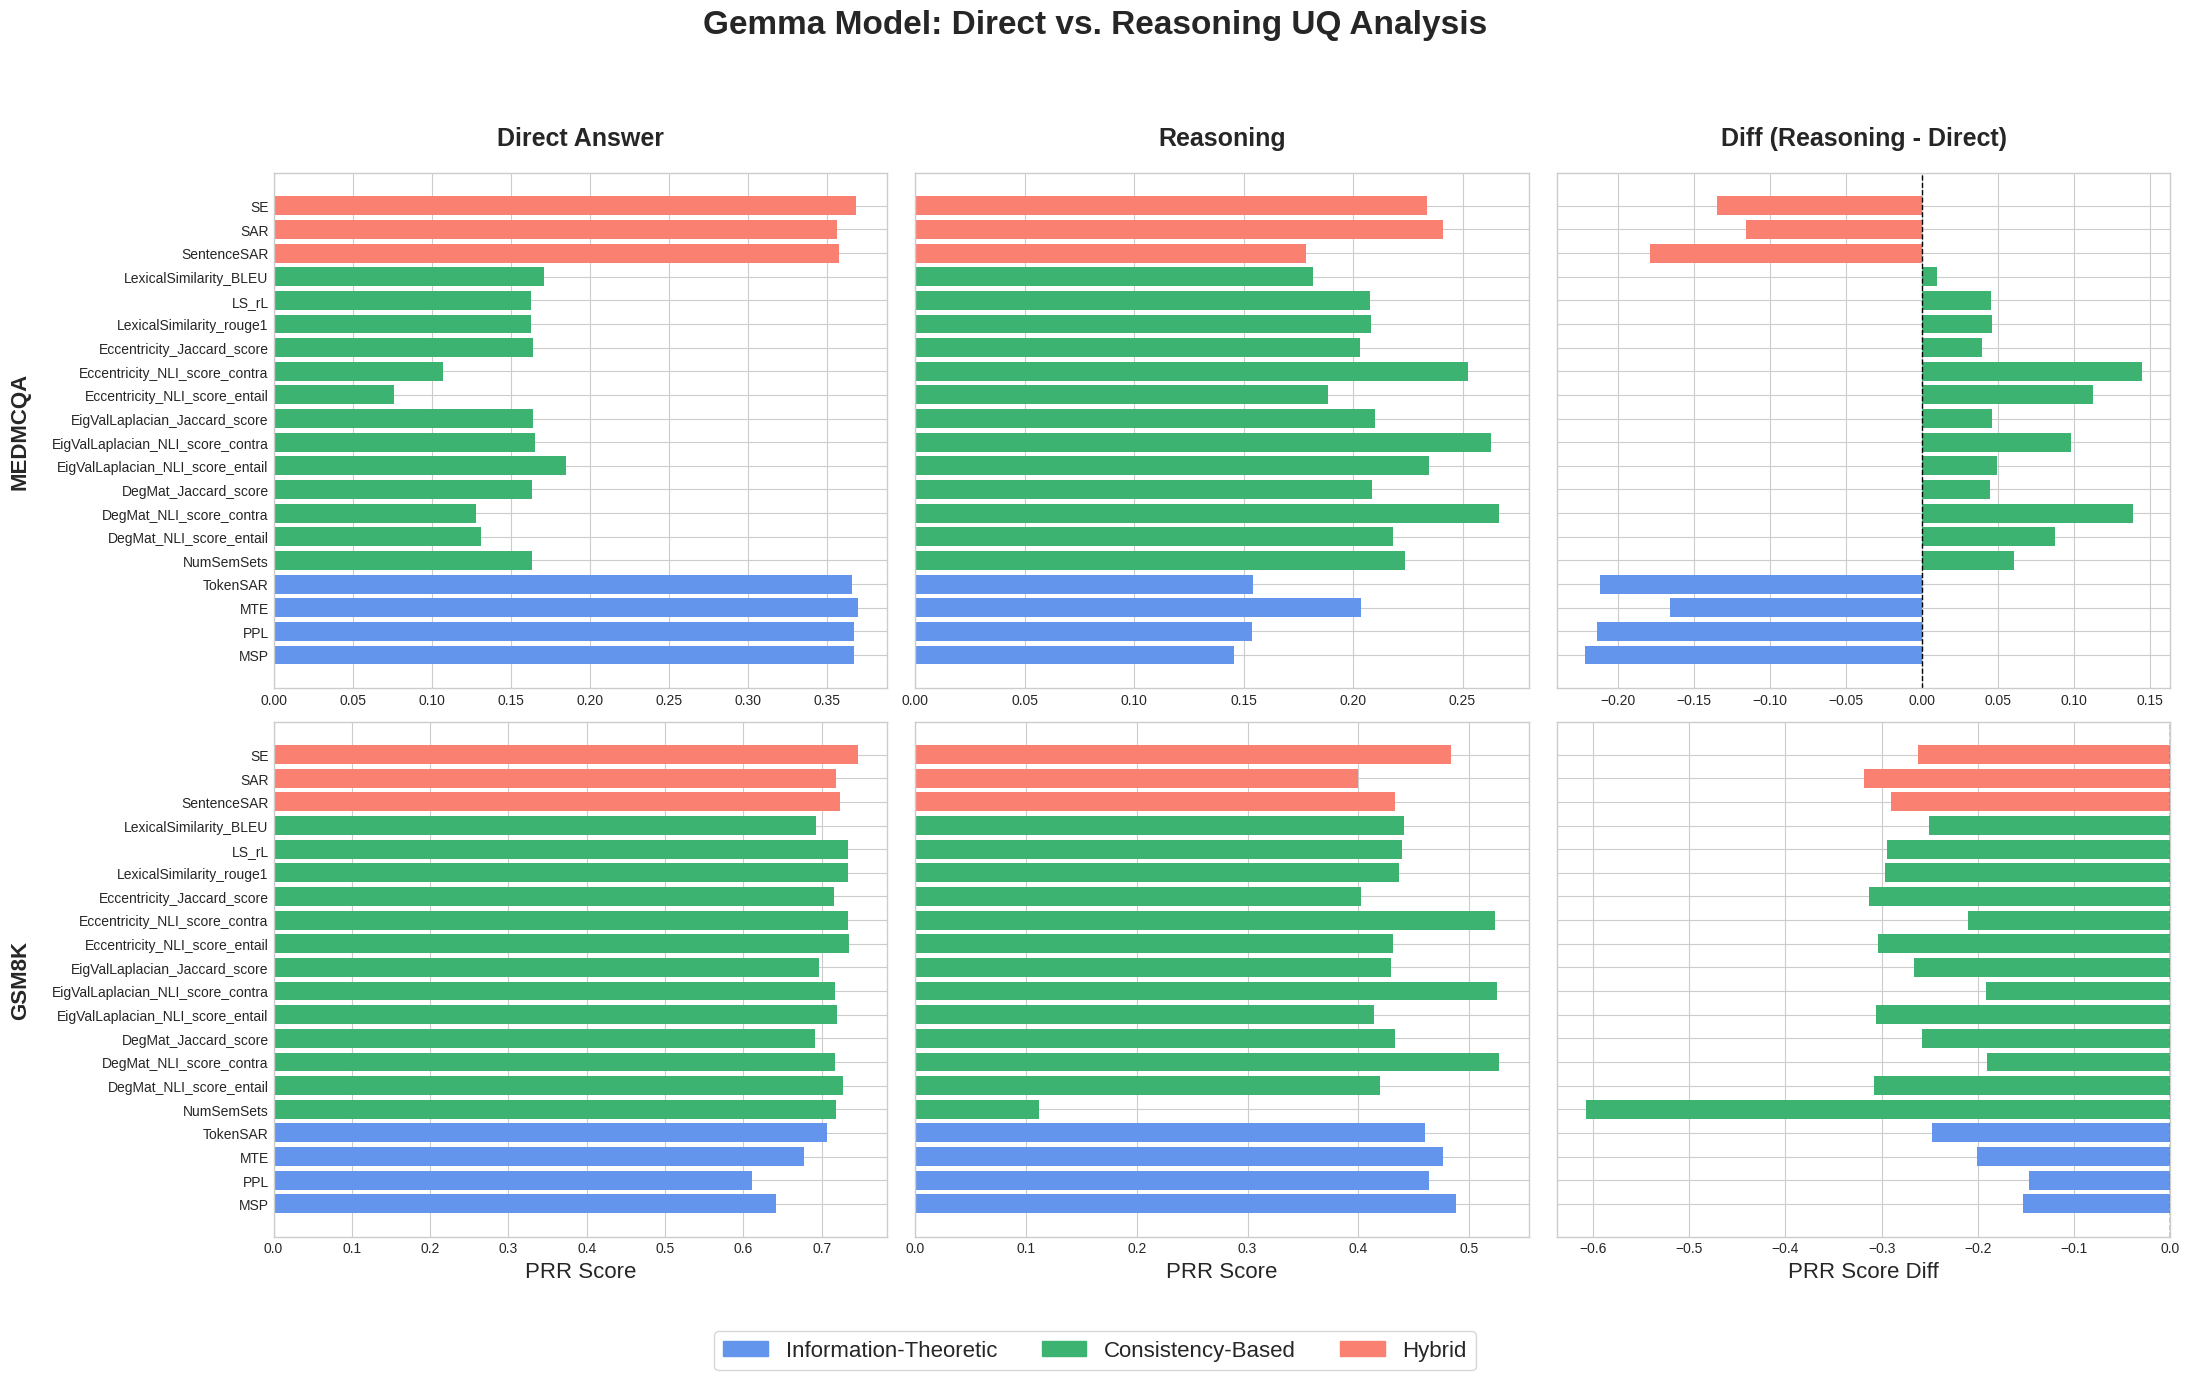

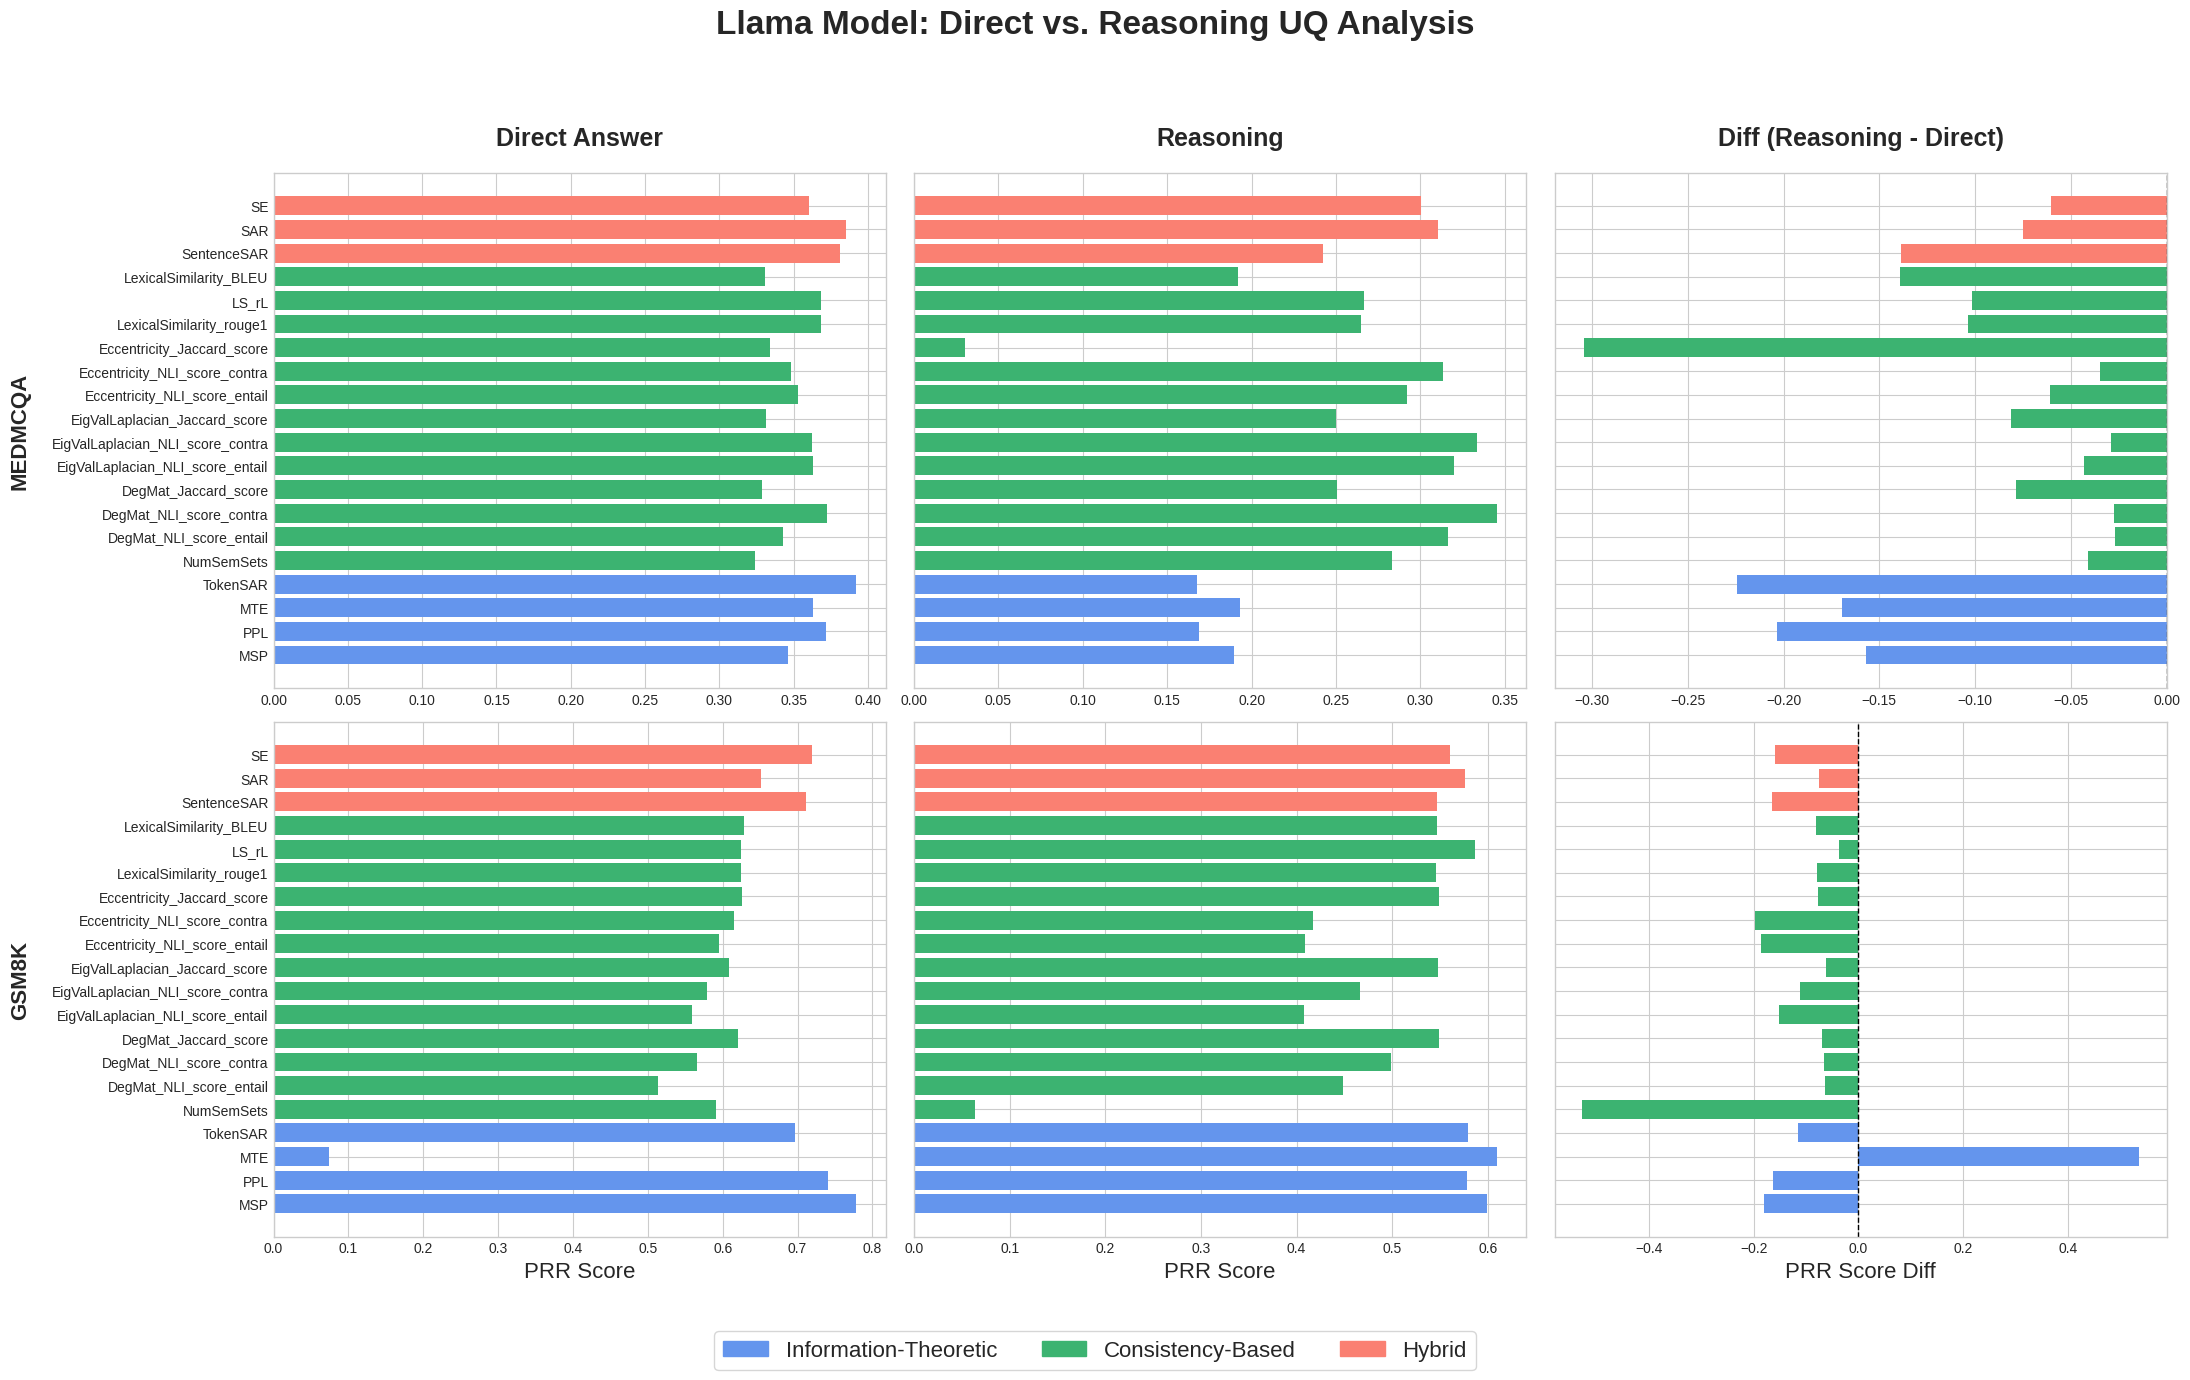

In [11]:
gen_model_plot('gemma', datasets, dataframes, 'Accuracy', color_map)
gen_model_plot('llama', datasets, dataframes, 'Accuracy', color_map)

## Comparison bar chart thingies idefk

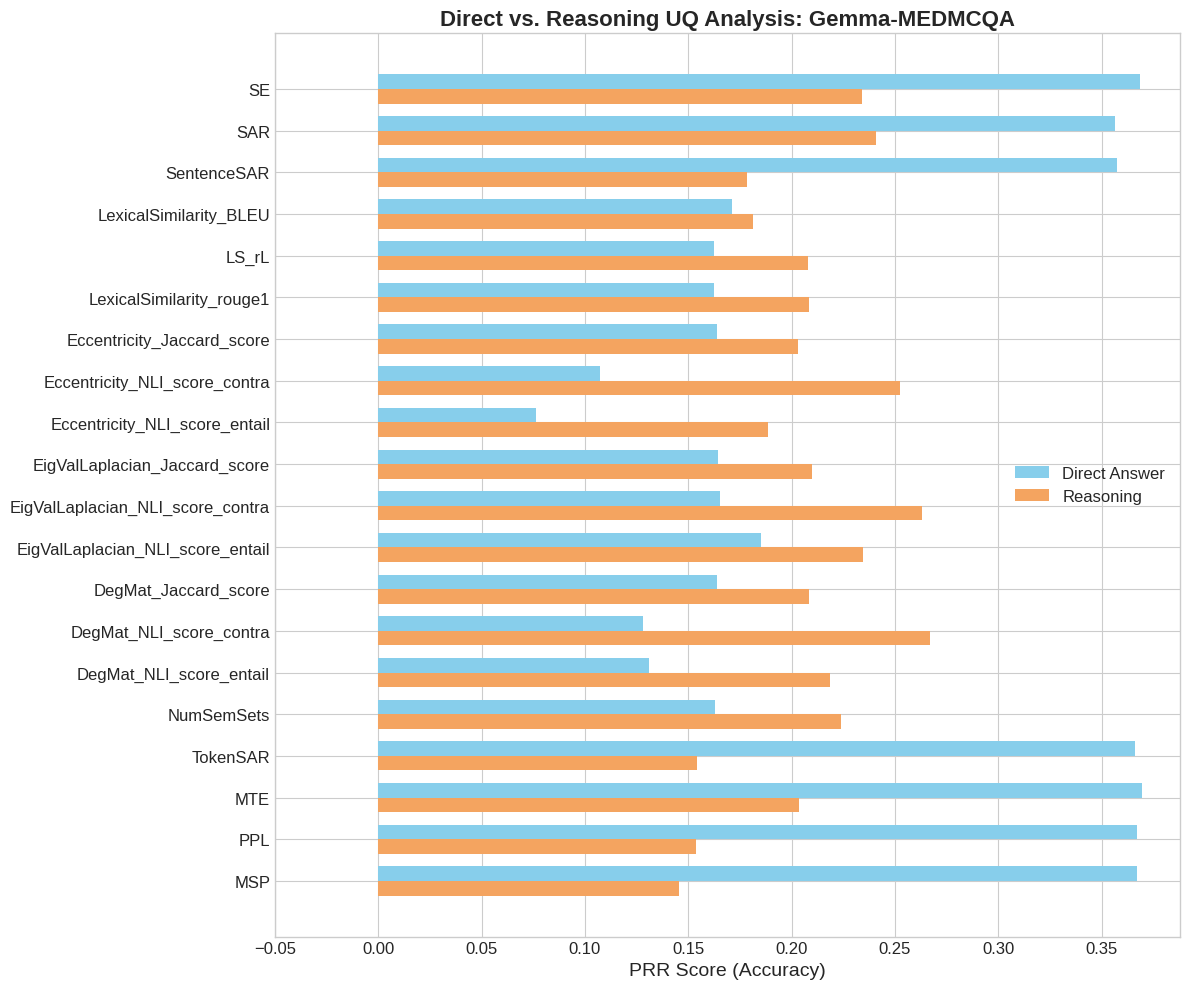

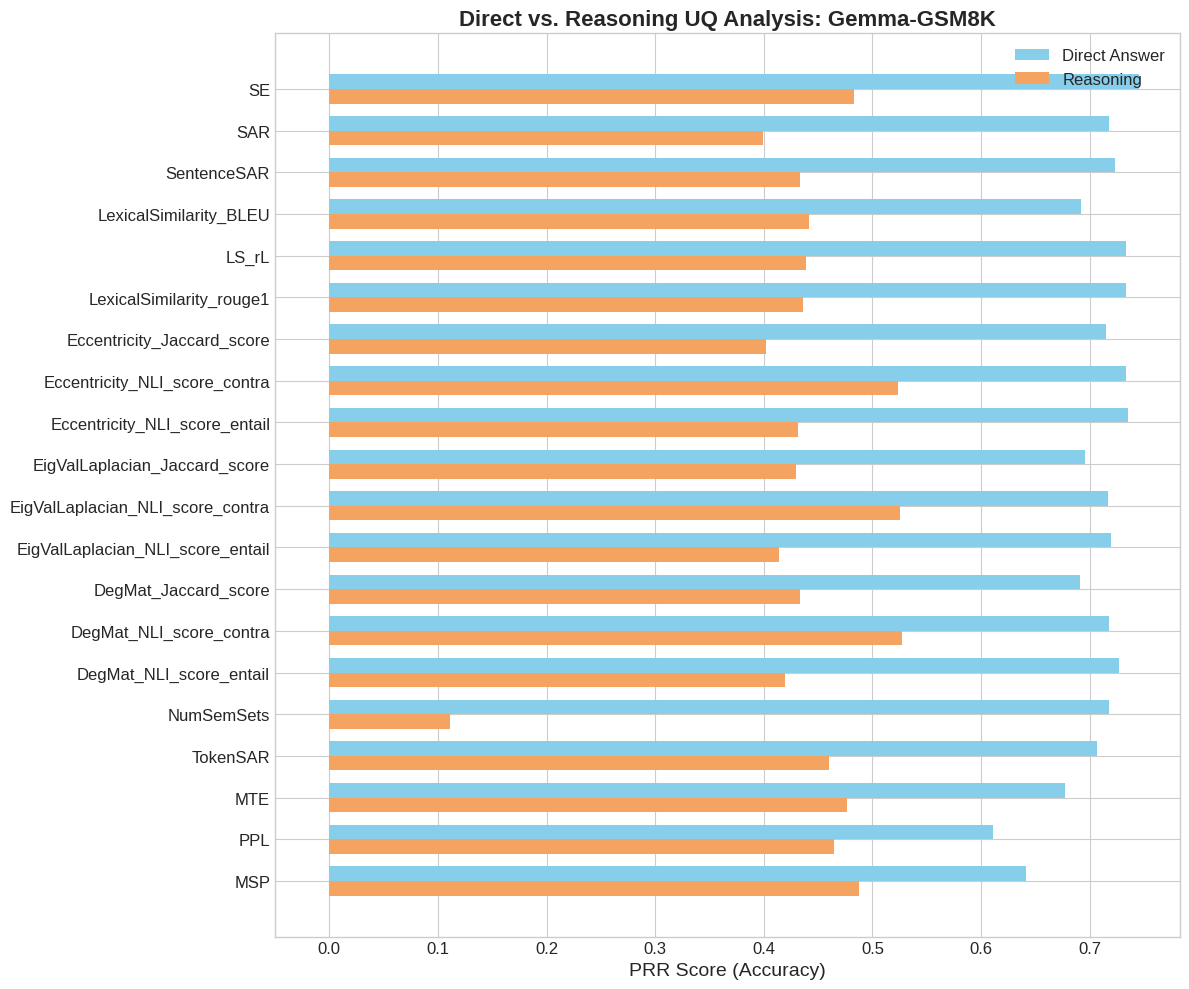

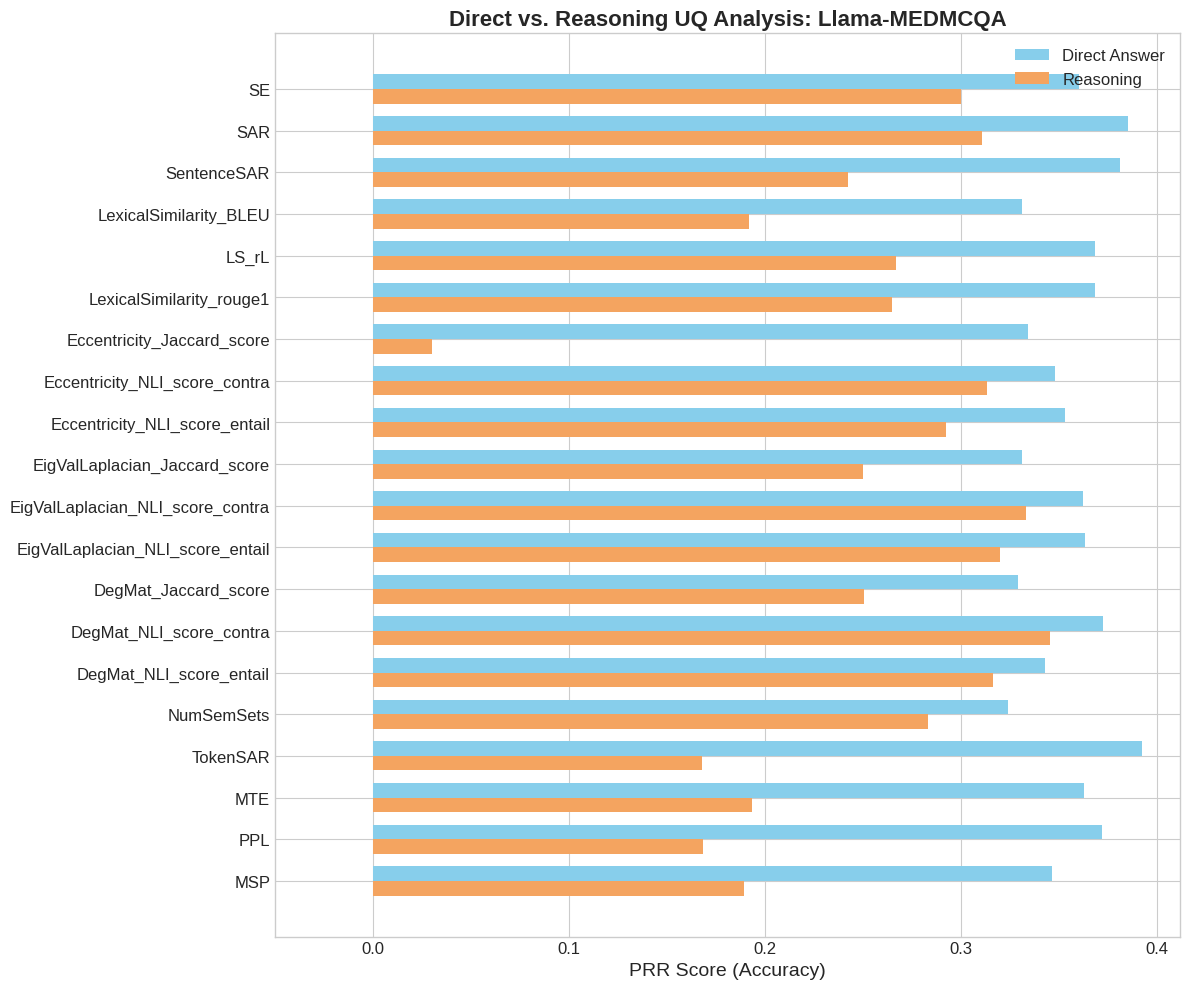

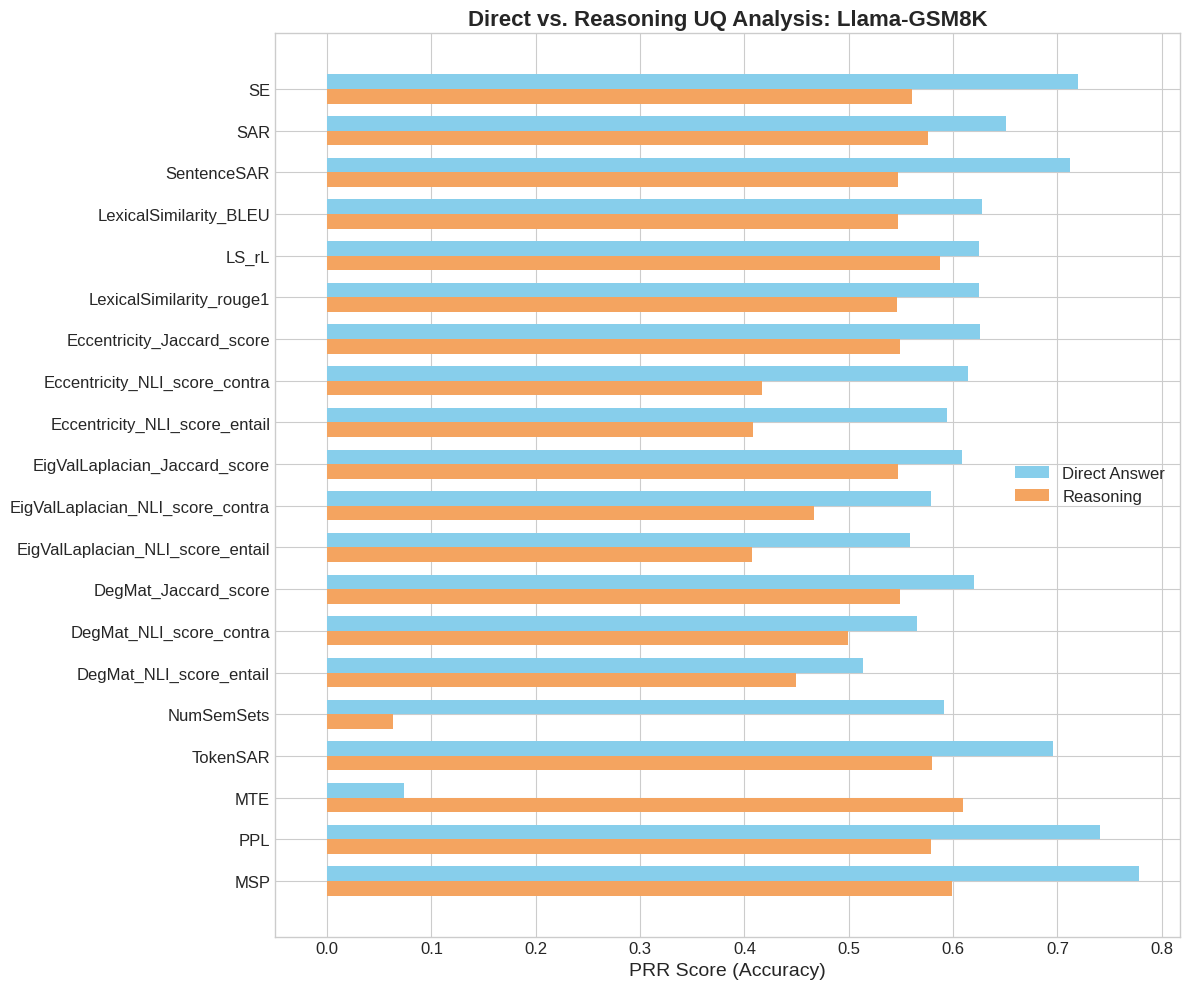

In [12]:
def create_grouped_bar_chart(model, dataset, dataframes, prr_metric, color_map):
    df_direct = dataframes.get(f'{model}_{dataset}_direct')
    df_reasoning = dataframes.get(f'{model}_{dataset}_reasoning')

    direct_scores = df_direct[prr_metric]
    reasoning_scores = df_reasoning[prr_metric]

    fig, ax = plt.subplots(figsize=(12, 10))
    y_pos = np.arange(len(direct_scores))
    bar_height = 0.35

    bars1 = ax.barh(y_pos + bar_height/2, direct_scores, bar_height, label='Direct Answer', color='skyblue')
    bars2 = ax.barh(y_pos - bar_height/2, reasoning_scores, bar_height, label='Reasoning', color='sandybrown')

    ax.set_xlabel(f'PRR Score ({prr_metric})', fontsize=14)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(direct_scores.index, fontsize=12)
    ax.tick_params(axis='x', labelsize=12)
    ax.set_title(f'Direct vs. Reasoning UQ Analysis: {model.capitalize()}-{dataset.upper()}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.set_xlim(left=min(0, direct_scores.min(), reasoning_scores.min()) - 0.05) # Ensure x-axis starts at or below 0
    
    fig.tight_layout()
    plt.show()

for model in models:
    for ds in datasets:
        create_grouped_bar_chart(model, ds, dataframes, 'Accuracy', color_map)


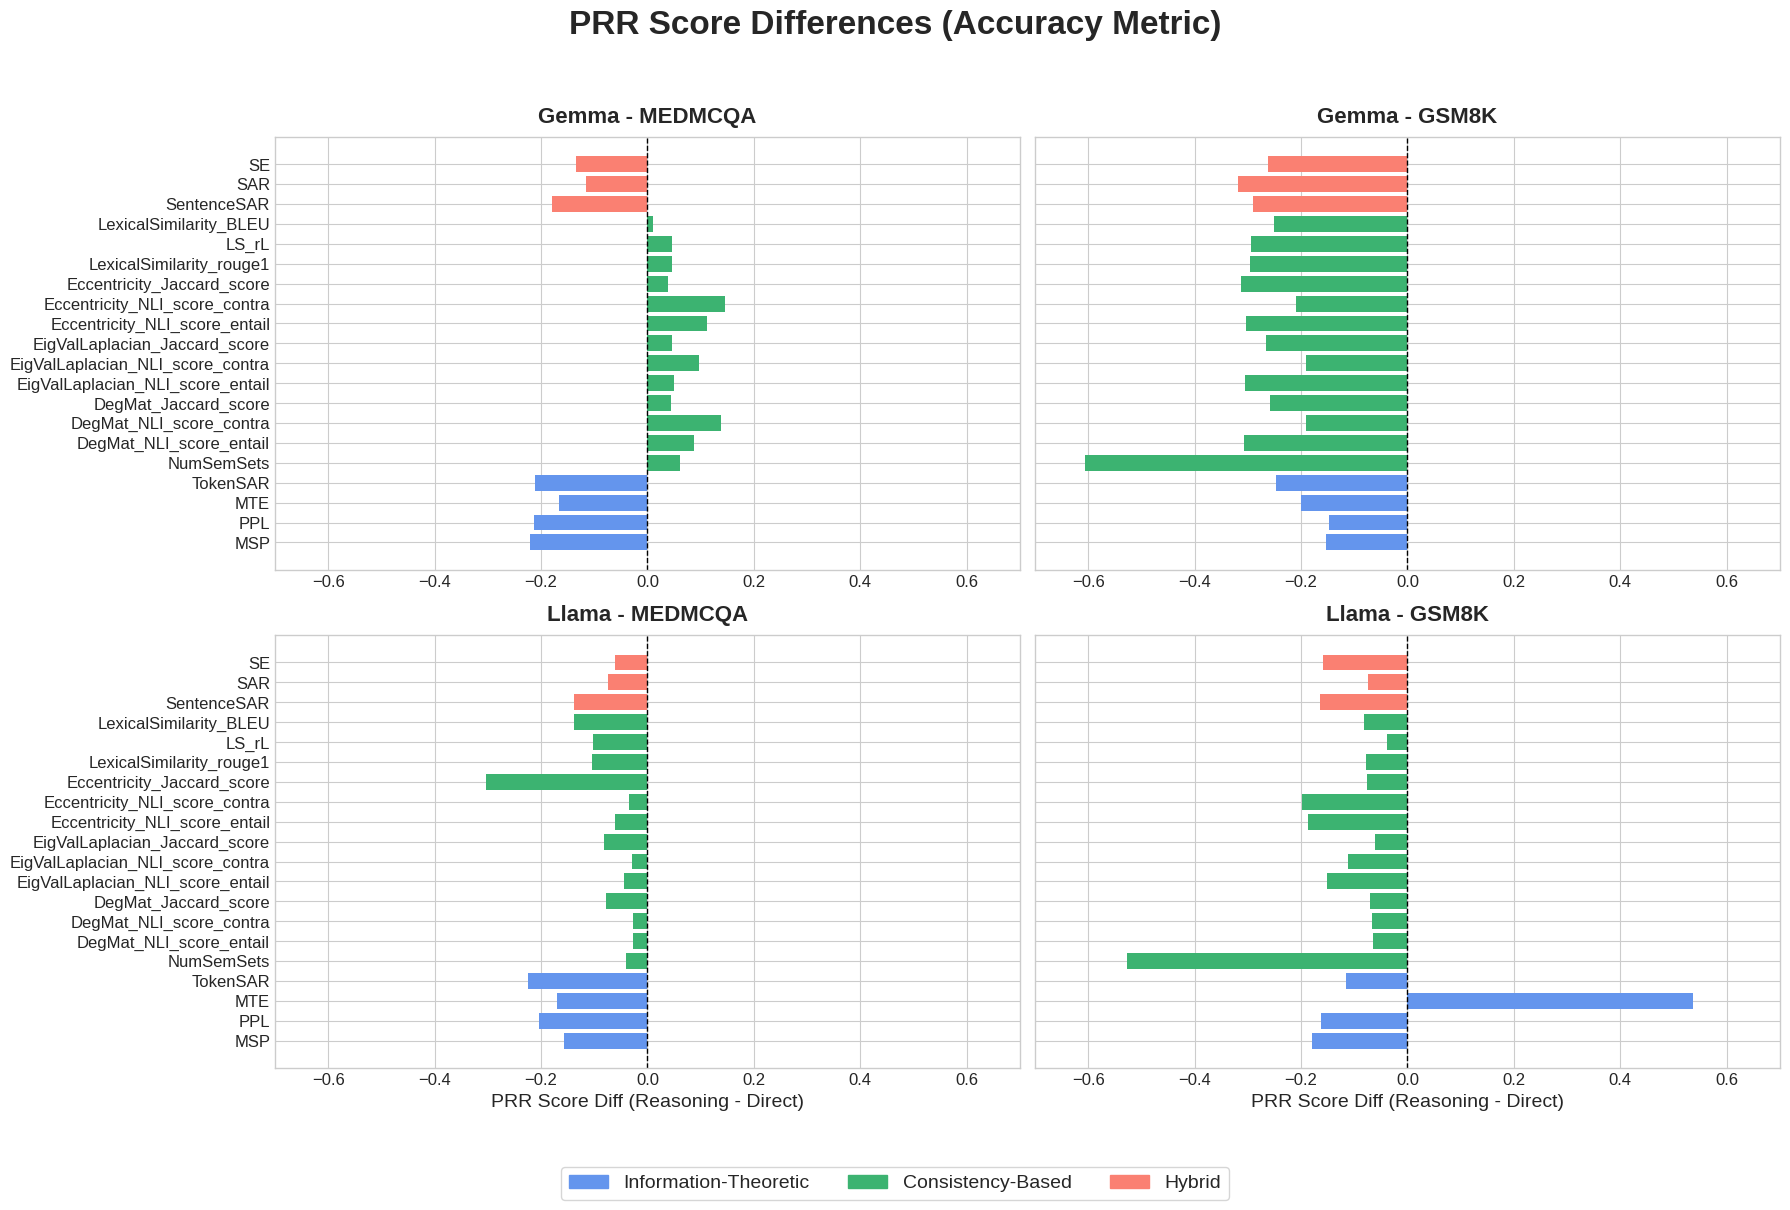

In [14]:
def create_diff_subplots(models, datasets, dataframes, prr_metric, color_map):
    """
    Generates a 2x2 grid of subplots, each showing the 'Diff (Reasoning - Direct)'
    for a specific model and dataset.
    """
    # Create a 2x2 figure for the four diff plots
    fig, axes = plt.subplots(len(models), len(datasets), figsize=(18, 12), sharey=True)
    # Flatten axes array for easier iteration if there's only one row/column
    if len(models) == 1 or len(datasets) == 1:
        axes = axes.flatten()
    else:
        axes = axes.reshape(len(models), len(datasets)) # Ensure it's a 2D array for indexing

    # Define font sizes for better readability
    title_fontsize = 20
    subtitle_fontsize = 16
    label_fontsize = 14
    tick_fontsize = 12
    legend_fontsize = 14

    for i, model_name in enumerate(models):
        for j, ds_name in enumerate(datasets):
            # Get the correct subplot axis
            ax = axes[i, j] if (len(models) > 1 and len(datasets) > 1) else axes[i * len(datasets) + j]

            df_direct = dataframes.get(f'{model_name}_{ds_name}_direct')
            df_reasoning = dataframes.get(f'{model_name}_{ds_name}_reasoning')

            direct_data = df_direct[prr_metric]
            reasoning_data = df_reasoning[prr_metric]
            diff_data = reasoning_data - direct_data

            # Create the bar chart for the diff data
            bars = ax.barh(diff_data.index, diff_data.values, color=[color_map.get(method, 'grey') for method in diff_data.index])
            ax.set_title(f'{model_name.capitalize()} - {ds_name.upper()}', fontsize=subtitle_fontsize, fontweight='bold', pad=10)
            ax.tick_params(axis='x', labelsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            ax.set_ylabel('') # Remove y-axis label for individual subplots
            ax.invert_yaxis() # Invert y-axis to have the first method at the top

            ax.set_xlim(-0.7, 0.7)

            # Add a vertical line at 0 for the diff plots
            ax.axvline(0, color='black', linestyle='--', linewidth=1)

            # Set x-axis label for the bottom row subplots
            if i == len(models) - 1: # Only for the bottom row
                ax.set_xlabel('PRR Score Diff (Reasoning - Direct)', fontsize=label_fontsize)

    # Main title for the entire figure
    fig.suptitle(f'PRR Score Differences ({prr_metric} Metric)',
                 fontsize=title_fontsize + 4, fontweight='bold', y=0.98) # Adjust y for title position

    # Create legend patches
    legend_patches = [
        mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
        mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
        mpatches.Patch(color='salmon', label='Hybrid')
    ]

    # Add a single legend at the bottom center
    fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=3, fontsize=legend_fontsize, frameon=True, title_fontsize=legend_fontsize)

    fig.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust rect to make space for the legend
    plt.show()

# Generate the combined diff plot
create_diff_subplots(models, datasets, dataframes, prr_metric_to_plot, color_map)


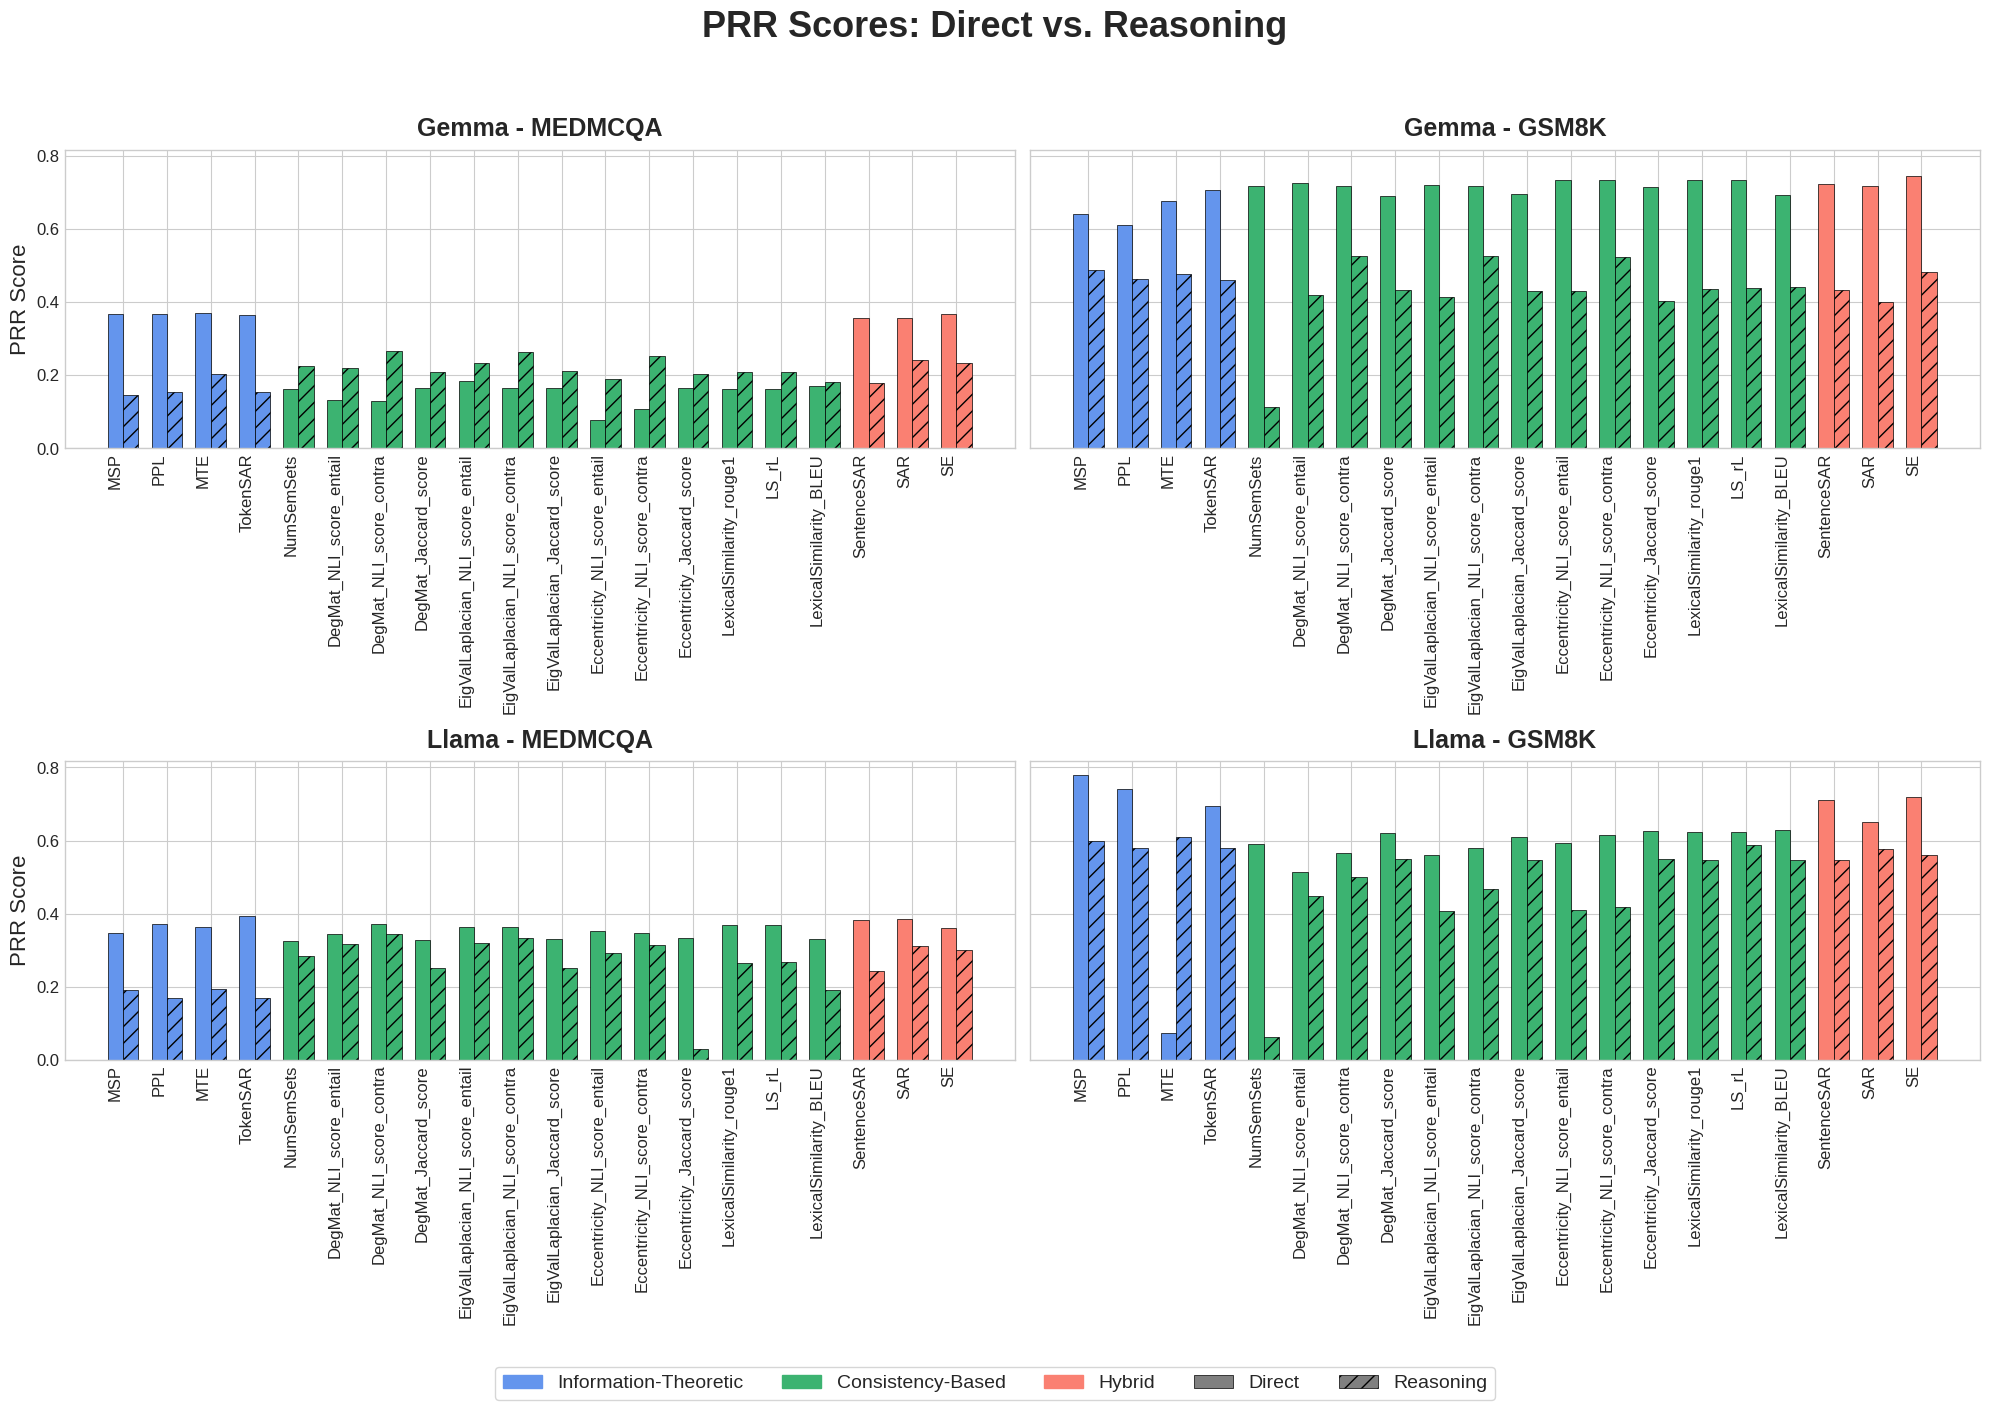

In [21]:
def create_direct_reasoning_subplots(models, datasets, dataframes, prr_metric, color_map):
    """
    Generates a 2x2 grid of subplots, each showing vertical bar charts for
    'Direct' and 'Reasoning' data for a specific model and dataset.
    Colors are based on method type, and shading differentiates Direct/Reasoning.
    """
    # Create a 2x2 figure for the four plots
    fig, axes = plt.subplots(len(models), len(datasets), figsize=(20, 14), sharey=True)
    
    # Ensure axes is a 2D array for consistent indexing, even if models or datasets is 1
    if len(models) == 1 or len(datasets) == 1:
        axes = axes.flatten().reshape(len(models), len(datasets))
    else:
        axes = axes.reshape(len(models), len(datasets))

    # Define font sizes for better readability
    title_fontsize = 22
    subtitle_fontsize = 18
    label_fontsize = 16
    tick_fontsize = 12
    legend_fontsize = 14

    for i, model_name in enumerate(models):
        for j, ds_name in enumerate(datasets):
            ax = axes[i, j]

            df_direct = dataframes.get(f'{model_name}_{ds_name}_direct')
            df_reasoning = dataframes.get(f'{model_name}_{ds_name}_reasoning')

            direct_data = df_direct[prr_metric]
            reasoning_data = df_reasoning[prr_metric]

            # Get method names for x-axis labels
            methods = direct_data.index
            x = np.arange(len(methods)) # The label locations for each group of bars

            bar_width = 0.35 # Width of the individual bars

            # Get colors for each method based on the color_map
            bar_colors = [color_map.get(method, 'grey') for method in methods]

            # Plot Direct bars with method-specific colors and black outline
            ax.bar(x - bar_width/2, direct_data.values, bar_width, color=bar_colors, edgecolor='black', linewidth=0.5)
            
            # Plot Reasoning bars with method-specific colors, a hatch pattern, and black outline
            ax.bar(x + bar_width/2, reasoning_data.values, bar_width, color=bar_colors, hatch='//', edgecolor='black', linewidth=0.5)

            # Set title for each subplot
            ax.set_title(f'{model_name.capitalize()} - {ds_name.upper()}', fontsize=subtitle_fontsize, fontweight='bold', pad=10)

            # Set x-axis ticks and labels
            ax.set_xticks(x)
            ax.set_xticklabels(methods, rotation=90, ha='right', fontsize=tick_fontsize) # Rotate labels for readability

            # Set y-axis label for the first column of subplots
            if j == 0:
                ax.set_ylabel(f'PRR Score', fontsize=label_fontsize)

            # Set y-axis limits (0 to 1 for Accuracy scores)
            # ax.set_ylim(0, 1)

            # Set y-tick font size
            ax.tick_params(axis='y', labelsize=tick_fontsize)

    # Main title for the entire figure
    fig.suptitle(f'PRR Scores: Direct vs. Reasoning',
                 fontsize=title_fontsize + 4, fontweight='bold', y=0.98) # Adjust y for title position

    # Create a global legend for the method types and their colors
    global_legend_patches = [
        mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
        mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
        mpatches.Patch(color='salmon', label='Hybrid')
    ]

    # Add patches for Direct and Reasoning styles to the global legend
    # Use a neutral color (grey) for these patches as their primary purpose is to show the fill/hatch
    direct_style_patch = mpatches.Patch(facecolor='grey', label='Direct', edgecolor='black', linewidth=0.5)
    reasoning_style_patch = mpatches.Patch(facecolor='grey', label='Reasoning', hatch='//', edgecolor='black', linewidth=0.5)

    # Combine all legend patches
    # The order here determines the order in the legend
    combined_legend_patches = global_legend_patches + [direct_style_patch, reasoning_style_patch]

    # Add a single global legend at the bottom center
    fig.legend(handles=combined_legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=5, fontsize=legend_fontsize, frameon=True, title_fontsize=legend_fontsize) # Increased ncol to accommodate more items

    # Adjust layout to prevent labels from overlapping
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Generate the combined plot with direct and reasoning data
create_direct_reasoning_subplots(models, datasets, dataframes, prr_metric_to_plot, color_map)
